## Import Libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

## Set the device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Download the Dataset from Google Drive

In [3]:
# Google Drive File ID
file_id = '1_LFismkS4gGJZs_GlmqAoLRg3OSFsR9v'

# Download the file
!gdown --id {file_id}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1_LFismkS4gGJZs_GlmqAoLRg3OSFsR9v
From (redirected): https://drive.google.com/uc?id=1_LFismkS4gGJZs_GlmqAoLRg3OSFsR9v&confirm=t&uuid=97789be7-63e6-48cb-ad0d-bd208570778e
To: /content/intel-image-classification.zip
100% 363M/363M [00:06<00:00, 55.3MB/s]


In [4]:
# Unzip the downloaded file
!unzip -q intel-image-classification.zip -d dataset

print("Dataset downloaded and unzipped successfully!")

Dataset downloaded and unzipped successfully!


## Data Preprocessing & Augmentation

In [5]:
# simple augmentations on the training set to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),      # Force all images to be 150x150
    transforms.RandomHorizontalFlip(),  # Randomly flip images left-to-right
    transforms.ToTensor(),              # Convert image to numbers (PyTorch Tensor)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Center the color values
])

# For the test/validation set, resize and convert
test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the dataset from the folders using PyTorch
train_dir = './dataset/seg_train/seg_train'
test_dir = './dataset/seg_test/seg_test'

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(test_dir, transform=test_transforms)

# Create DataLoaders to feed the data in batches
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Print the classes
class_names = train_data.classes
print(f"Classes found: {class_names}")
print(f"Total training images: {len(train_data)}")
print(f"Total test images: {len(test_data)}")

Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total training images: 14034
Total test images: 3000


## Define CNN Architecture

In [6]:
import torch.nn.functional as F
from torchsummary import summary

# MODEL 1: The Base Model (Without Regularization)
class BaseCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(BaseCNN, self).__init__()
        # Convolutional Layers (Extracting features like edges and textures)
        # Input image: 3 channels (RGB), Output: 16 channels, Kernel (filter) size: 3x3
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Pooling Layer (Reduces the size of the image representation by half)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # After 3 max pools, a 150x150 image becomes 18x18.
        # 64 channels * 18 * 18 = 20736 input features to the linear layer
        self.fc1 = nn.Linear(64 * 18 * 18, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass through Conv -> ReLU activation -> MaxPool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the 3D tensor into a 1D vector for the linear layers
        x = x.view(-1, 64 * 18 * 18)

        x = F.relu(self.fc1(x))
        x = self.fc2(x) # Output layer (no activation, apply it in the loss function)
        return x

# MODEL 2: The Regularized Model (With BatchNorm and Dropout)
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(RegularizedCNN, self).__init__()

        # Same Convolutional Layers
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        # Batch Normalization normalizes the outputs of the conv layer
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        # Same Fully Connected Layers
        self.fc1 = nn.Linear(64 * 18 * 18, 512)
        # Dropout randomly zeroes some elements to prevent overfitting
        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv -> BatchNorm -> ReLU -> MaxPool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 64 * 18 * 18)

        # Apply dropout before the fully connected layers
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

base_model = BaseCNN().to(device)
reg_model = RegularizedCNN().to(device)

print("BASE CNN ARCHITECTURE SUMMARY")
summary(base_model, input_size=(3, 150, 150))

print("\n\n REGULARIZED CNN ARCHITECTURE SUMMARY")
summary(reg_model, input_size=(3, 150, 150))

BASE CNN ARCHITECTURE SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 150, 150]             448
         MaxPool2d-2           [-1, 16, 75, 75]               0
            Conv2d-3           [-1, 32, 75, 75]           4,640
         MaxPool2d-4           [-1, 32, 37, 37]               0
            Conv2d-5           [-1, 64, 37, 37]          18,496
         MaxPool2d-6           [-1, 64, 18, 18]               0
            Linear-7                  [-1, 512]      10,617,344
            Linear-8                    [-1, 6]           3,078
Total params: 10,644,006
Trainable params: 10,644,006
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.26
Forward/backward pass size (MB): 5.97
Params size (MB): 40.60
Estimated Total Size (MB): 46.83
----------------------------------------------------------------


 R

## Training Loop with Validation

In [7]:
import copy
import time

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizers: Adam
# separate optimizer for each model
optimizer_base = optim.Adam(base_model.parameters(), lr=0.001)
optimizer_reg = optim.Adam(reg_model.parameters(), lr=0.001)

# Learning Rate Schedulers
scheduler_base = optim.lr_scheduler.StepLR(optimizer_base, step_size=10, gamma=0.5)
scheduler_reg = optim.lr_scheduler.StepLR(optimizer_reg, step_size=10, gamma=0.5)

# The Training Function
def train_model(model, optimizer, scheduler, num_epochs, model_name):
    print(f"--- Starting Training for {model_name} ---")
    start_time = time.time()

    # Dictionaries to store metrics
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = test_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass and optimize
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step() # Step the learning rate scheduler

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save history for plotting
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Deep copy the model if it's the best validation accuracy we've seen
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # Save the .pth file
                torch.save(model.state_dict(), f'{model_name}_best.pth')

        print()

    time_elapsed = time.time() - start_time
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_acc:4f}\n')

    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return model, history

# Execute Training
epochs = 30

# Train Base Model
base_model, base_history = train_model(base_model, optimizer_base, scheduler_base, num_epochs=epochs, model_name="BaseCNN")

# Train Regularized Model
reg_model, reg_history = train_model(reg_model, optimizer_reg, scheduler_reg, num_epochs=epochs, model_name="RegularizedCNN")

--- Starting Training for BaseCNN ---
Epoch 1/30
----------
Train Loss: 0.8586 Acc: 0.6677
Val Loss: 0.6293 Acc: 0.7703

Epoch 2/30
----------
Train Loss: 0.5705 Acc: 0.7907
Val Loss: 0.5682 Acc: 0.8047

Epoch 3/30
----------
Train Loss: 0.4657 Acc: 0.8333
Val Loss: 0.4809 Acc: 0.8347

Epoch 4/30
----------
Train Loss: 0.3745 Acc: 0.8633
Val Loss: 0.5430 Acc: 0.8050

Epoch 5/30
----------
Train Loss: 0.3098 Acc: 0.8874
Val Loss: 0.4831 Acc: 0.8410

Epoch 6/30
----------
Train Loss: 0.2396 Acc: 0.9158
Val Loss: 0.4959 Acc: 0.8423

Epoch 7/30
----------
Train Loss: 0.1821 Acc: 0.9358
Val Loss: 0.5606 Acc: 0.8393

Epoch 8/30
----------
Train Loss: 0.1489 Acc: 0.9488
Val Loss: 0.6426 Acc: 0.8270

Epoch 9/30
----------
Train Loss: 0.1119 Acc: 0.9634
Val Loss: 0.7057 Acc: 0.8253

Epoch 10/30
----------
Train Loss: 0.0918 Acc: 0.9712
Val Loss: 0.7243 Acc: 0.8403

Epoch 11/30
----------
Train Loss: 0.0392 Acc: 0.9898
Val Loss: 0.7336 Acc: 0.8413

Epoch 12/30
----------
Train Loss: 0.0232 Acc: 

In [10]:
# Calculate and print the best metrics from the Regularized CNN history
best_acc_percent = max(reg_history['val_acc']) * 100
best_loss = min(reg_history['val_loss'])

print(f"Best Accuracy Value: {best_acc_percent:.2f}")
print(f"Best Loss Value: {best_loss:.4f}")

Best Accuracy Value: 88.63
Best Loss Value: 0.3797


## Visualizations

Plotting Base CNN Curves (the validation line separating from the training line is overfitting)


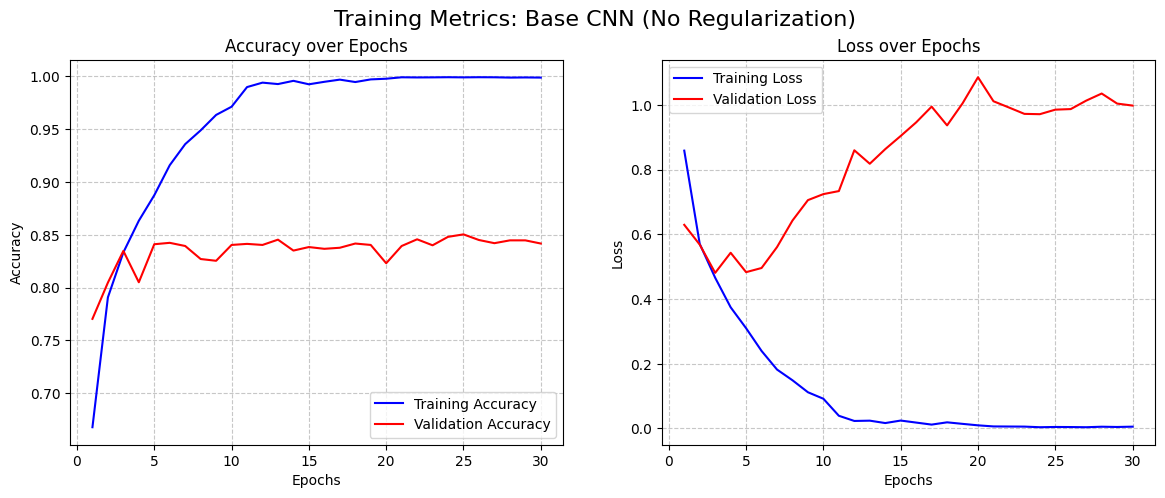

Plotting Regularized CNN Curves (The validation line should stay closer to the training line)


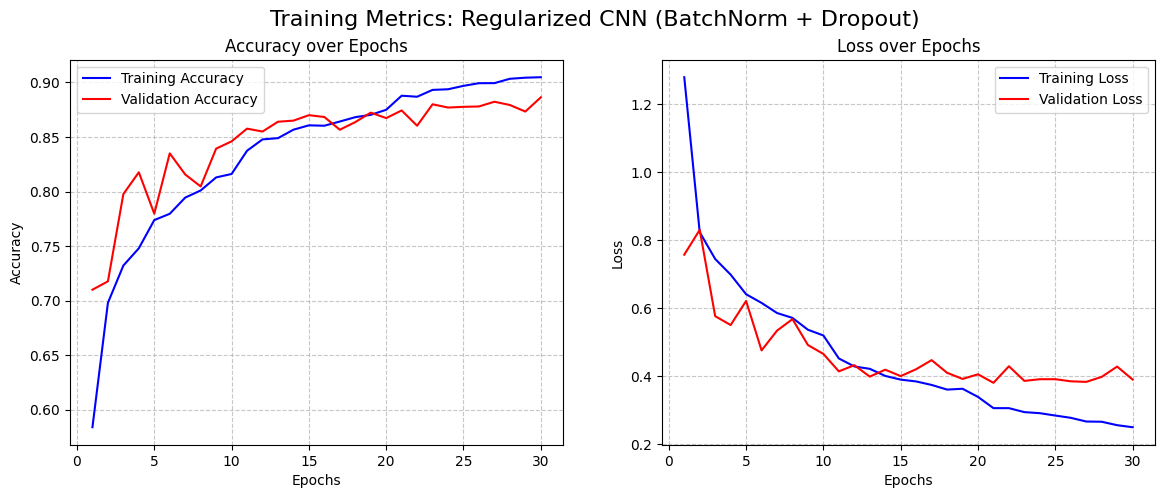

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    epochs = range(1, len(history['train_acc']) + 1)

    # two subplots for Accuracy and Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Metrics: {model_name}', fontsize=16)

    # Plot Accuracy
    ax1.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    ax1.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot Loss
    ax2.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    ax2.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.show()

# Plot the curves for both models
print("Plotting Base CNN Curves (the validation line separating from the training line is overfitting)")
plot_history(base_history, "Base CNN (No Regularization)")

print("Plotting Regularized CNN Curves (The validation line should stay closer to the training line)")
plot_history(reg_history, "Regularized CNN (BatchNorm + Dropout)")

## Model Evaluation

Evaluating model on test set

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   buildings       0.86      0.86      0.86       437
      forest       0.96      0.97      0.97       474
     glacier       0.87      0.82      0.85       553
    mountain       0.83      0.87      0.85       525
         sea       0.90      0.92      0.91       510
      street       0.90      0.87      0.88       501

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



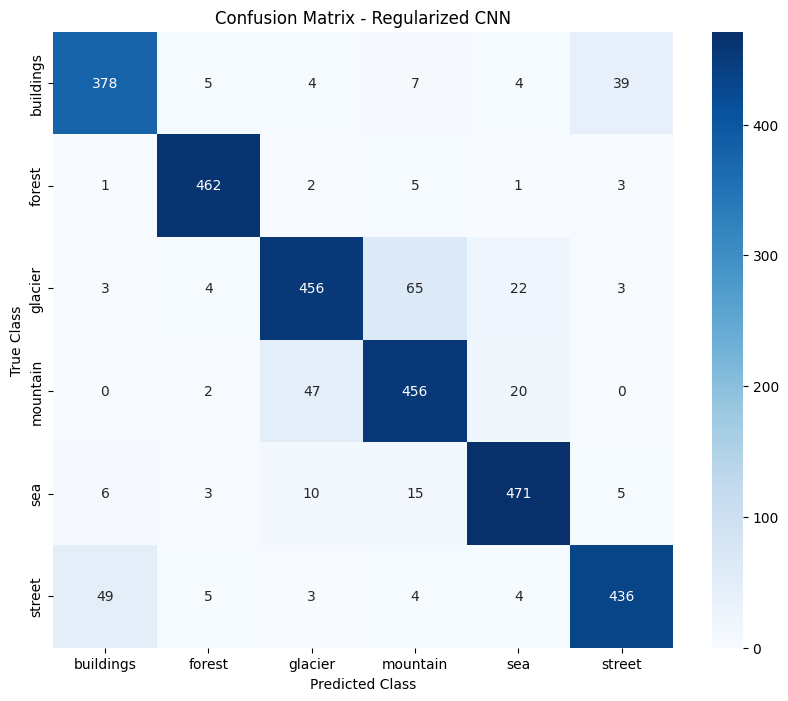

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_model(model, dataloader, classes):
    model.eval() # Set to evaluation mode
    all_preds = []
    all_labels = []

    print("Evaluating model on test set")

    # Disable gradient tracking for testing
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Print Comprehensive Metrics (Precision, Recall, F1)
    print("\nCLASSIFICATION REPORT")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix - Regularized CNN')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

    return all_labels, all_preds

# Run the evaluation on regularized model
true_labels, predictions = evaluate_model(reg_model, test_loader, class_names)

## MODEL PREDICTIONS

Fetching a random mix of images and making predictions...



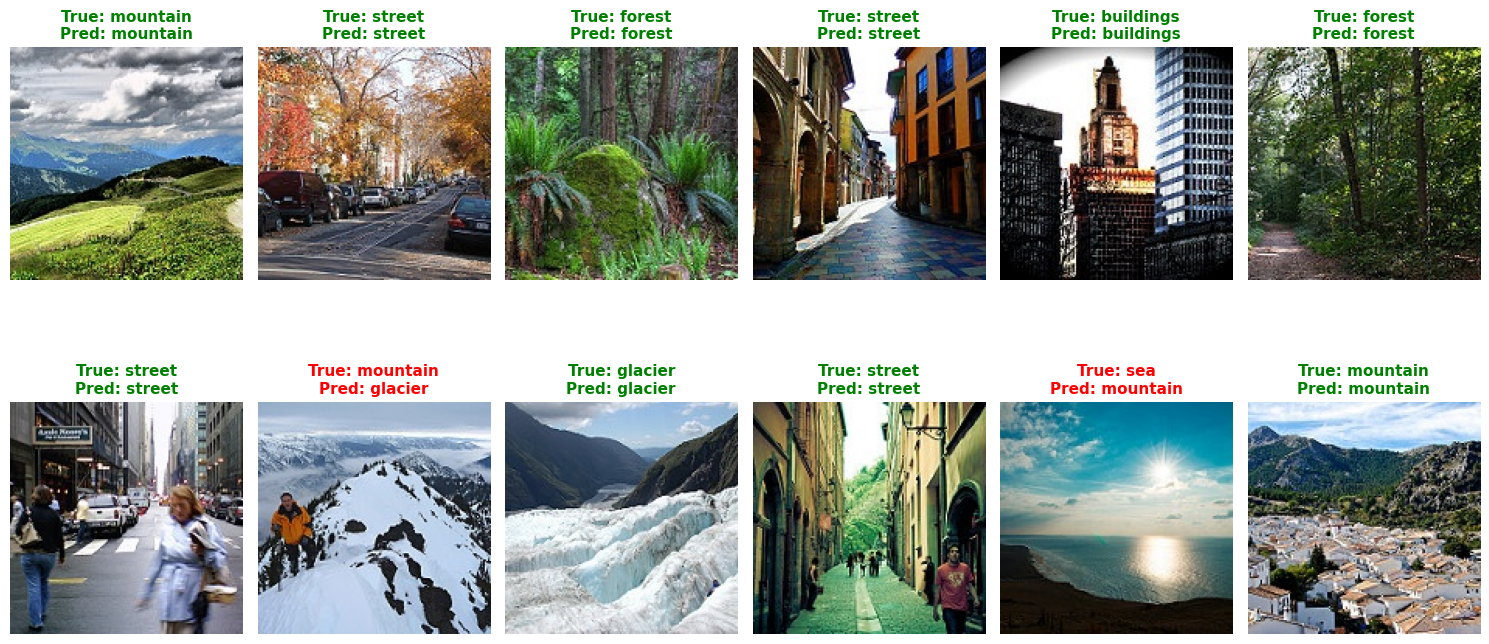

In [17]:
def imshow(inp, title=None, is_correct=True):
    # Convert PyTorch tensor to numpy array and fix the color channels
    inp = inp.numpy().transpose((1, 2, 0))

    # Un-normalize the image
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Ensure colors stay in valid range

    plt.imshow(inp)

    # Make the title text green if the prediction was right, red if wrong
    color = 'green' if is_correct else 'red'
    if title is not None:
        plt.title(title, color=color, fontweight='bold', fontsize=11)
    plt.axis('off') # Hide the grid lines

def visualize_sample_predictions(model, dataloader, class_names, num_images=12):
    model.eval() # Set to evaluation mode
    images_so_far = 0

    # Adjust figure size based on how many images we are showing
    plt.figure(figsize=(15, 8))

    print("Fetching a random mix of images and making predictions...\n")

    # Disable gradient tracking for testing
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Get the model's guesses
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Loop through the batch and plot the requested number of images
            for j in range(inputs.size()[0]):
                images_so_far += 1

                # Create a grid for the images (2 rows, flexible columns)
                ax = plt.subplot(2, num_images // 2, images_so_far)

                true_label = class_names[labels[j]]
                predicted_label = class_names[preds[j]]
                is_correct = true_label == predicted_label

                title = f'True: {true_label}\nPred: {predicted_label}'

                imshow(inputs.cpu().data[j], title, is_correct)

                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

# dataloader for visualization that shuffles the images
vis_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=True)

# Run the visualization
visualize_sample_predictions(reg_model, vis_loader, class_names, num_images=12)